In [1]:
import pandas as pd

In [2]:
df_prod = pd.read_excel(r'data/prod_vs_demand.xlsx', sheet_name='PRODUCTION')
df_demand = pd.read_excel(r'data/prod_vs_demand.xlsx', sheet_name='DEMAND')

In [3]:
df_prod.columns

Index(['Mineral', 'Year', 'Scenario', 'Value', 'Unit', 'Value_t_mining',
       'Value_t_refining'],
      dtype='object')

In [4]:
#df_prod.columns = df_prod.columns.str.strip()

In [5]:
df_demand = df_demand[df_demand['Scenario'] != 'Global Net-zero']

In [6]:
df_demand

,Scenario,Country,Year,Technology,Metal,Metal_demand_t,Mode,Powertain,Powertrain
0,Canada Net-zero,Canada,2021,Bioenergy,Cobalt,5.086200,NaN,NaN,NaN
1,Canada Net-zero,Canada,2021,Bioenergy,Copper,5652.039750,NaN,NaN,NaN
2,Canada Net-zero,Canada,2021,Bioenergy,Nickel,50.862000,NaN,NaN,NaN
3,Canada Net-zero,Canada,2022,Bioenergy,Cobalt,5.086200,NaN,NaN,NaN
4,Canada Net-zero,Canada,2022,Bioenergy,Copper,5652.039750,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
12556,Canada Net-zero,Canada,2050,Vehicle motor,Neodymium,0.740288,Trucks,NaN,FCEV
12557,Canada Net-zero,Canada,2050,Vehicle motor,Copper,41423.359354,Cars,NaN,PHEV
12558,Canada Net-zero,Canada,2050,Vehicle motor,Neodymium,2073.480122,Cars,NaN,PHEV
12559,Canada Net-zero,Canada,2050,Vehicle motor,Copper,8371.263293,Vans,NaN,PHEV


In [7]:
def plot_prod_vs_demand_totals_facets_clean(
    df_prod,
    df_demand,
    metals=None,
    prod_scen_col="Scenario",
    demand_scen_col="Scenario",
    year_col="Year",
    demand_value_col="Metal_demand_t",
    prod_value_col="Value_t_refining",
    figsize=(14, 8),
    dpi=350,
    savepath='results/Prod_vs_demand/Prod_vs_demand'
):
    """
    Clean comparison of production vs demand totals, every 5 years (2020–2040).

    NEW: df_prod now has columns:
        Mineral | Year | Scenario | Value | Unit | Value_t_mining | Value_t_refining

    This function compares:
        - PRODUCTION   → df_prod[prod_value_col]
        - DEMAND       → df_demand[demand_value_col]
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch

    # --- Production already in LONG format ---
    prod_long = df_prod.copy()
    prod_long = prod_long.rename(columns={"Mineral": "Metal"})
    prod_long["Production_t"] = prod_long[prod_value_col]

    # --- Filter years ---
    prod_long = prod_long[
        prod_long[year_col].between(2020, 2040) &
        (prod_long[year_col] % 5 == 0)
    ]

    df_demand = df_demand[
        df_demand[year_col].between(2020, 2040) &
        (df_demand[year_col] % 5 == 0)
    ]

    # --- Metals ---
    if metals is None:
        metals = sorted(df_demand["Metal"].dropna().unique())

    # --- Aggregate demand ---
    df_demand_total = (
        df_demand.groupby([demand_scen_col, year_col, "Metal"])[demand_value_col]
        .sum()
        .reset_index()
    )

    # --- Colors ---
    prod_scenarios = sorted(prod_long[prod_scen_col].unique())
    demand_scenarios = sorted(df_demand_total[demand_scen_col].unique())

    prod_colors = sns.color_palette("Greens", len(prod_scenarios))
    demand_colors = sns.color_palette("Reds", len(demand_scenarios))

    color_map = dict(zip(prod_scenarios + demand_scenarios,
                         prod_colors + demand_colors))

    # --- Figure setup ---
    n_metals = len(metals)
    ncols = 3
    nrows = int(np.ceil(n_metals / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, dpi=dpi)
    axes = axes.flatten()

    bar_width = 0.15
    group_offset = 0.2

    for i, metal in enumerate(metals):
        ax = axes[i]

        d_prod = prod_long[prod_long["Metal"] == metal]
        d_demand = df_demand_total[df_demand_total["Metal"] == metal]

        if d_prod.empty and d_demand.empty:
            ax.set_visible(False)
            continue

        all_years = sorted(set(d_prod[year_col]) | set(d_demand[year_col]))
        x = np.arange(len(all_years))

        # --- Production bars ---
        for j, scen in enumerate(prod_scenarios):
            sub = (
                d_prod[d_prod[prod_scen_col] == scen]
                .set_index(year_col)
                .reindex(all_years)
                .fillna(0)
            )

            ax.bar(
                x - group_offset + j * bar_width,
                sub["Production_t"],
                width=bar_width,
                color=color_map[scen],
                label=f"Prod – {scen}" if i == 0 else "",
                alpha=0.9,
            )

        # --- Demand bars ---
        for j, scen in enumerate(demand_scenarios):
            sub = (
                d_demand[d_demand[demand_scen_col] == scen]
                .set_index(year_col)
                .reindex(all_years)
                .fillna(0)
            )

            ax.bar(
                x + group_offset + j * bar_width,
                sub[demand_value_col],
                width=bar_width,
                color=color_map[scen],
                label=f"Demand – {scen}" if i == 0 else "",
                alpha=0.9,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(all_years, fontsize=8)
        ax.set_title(metal, fontsize=10)
        ax.tick_params(axis="y", labelsize=8)
        ax.grid(True, axis="y", linestyle=":", alpha=0.4)

    # --- Hide unused axes ---
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # --- Legend ---
    handles = [Patch(color=color_map[s], label=s)
               for s in (prod_scenarios + demand_scenarios)]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=4,
        fontsize=12,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01)
    )

    fig.tight_layout(rect=[0, 0.07, 1, 1])

    if savepath:
        fig.savefig(f"{savepath}.png", bbox_inches="tight")
        fig.savefig(f"{savepath}.svg", bbox_inches="tight")
        print(f"Saved to {savepath}.png and .svg")

    plt.show()


Saved to results/Prod_vs_demand/Prod_vs_demand_selected_metals.png and .svg


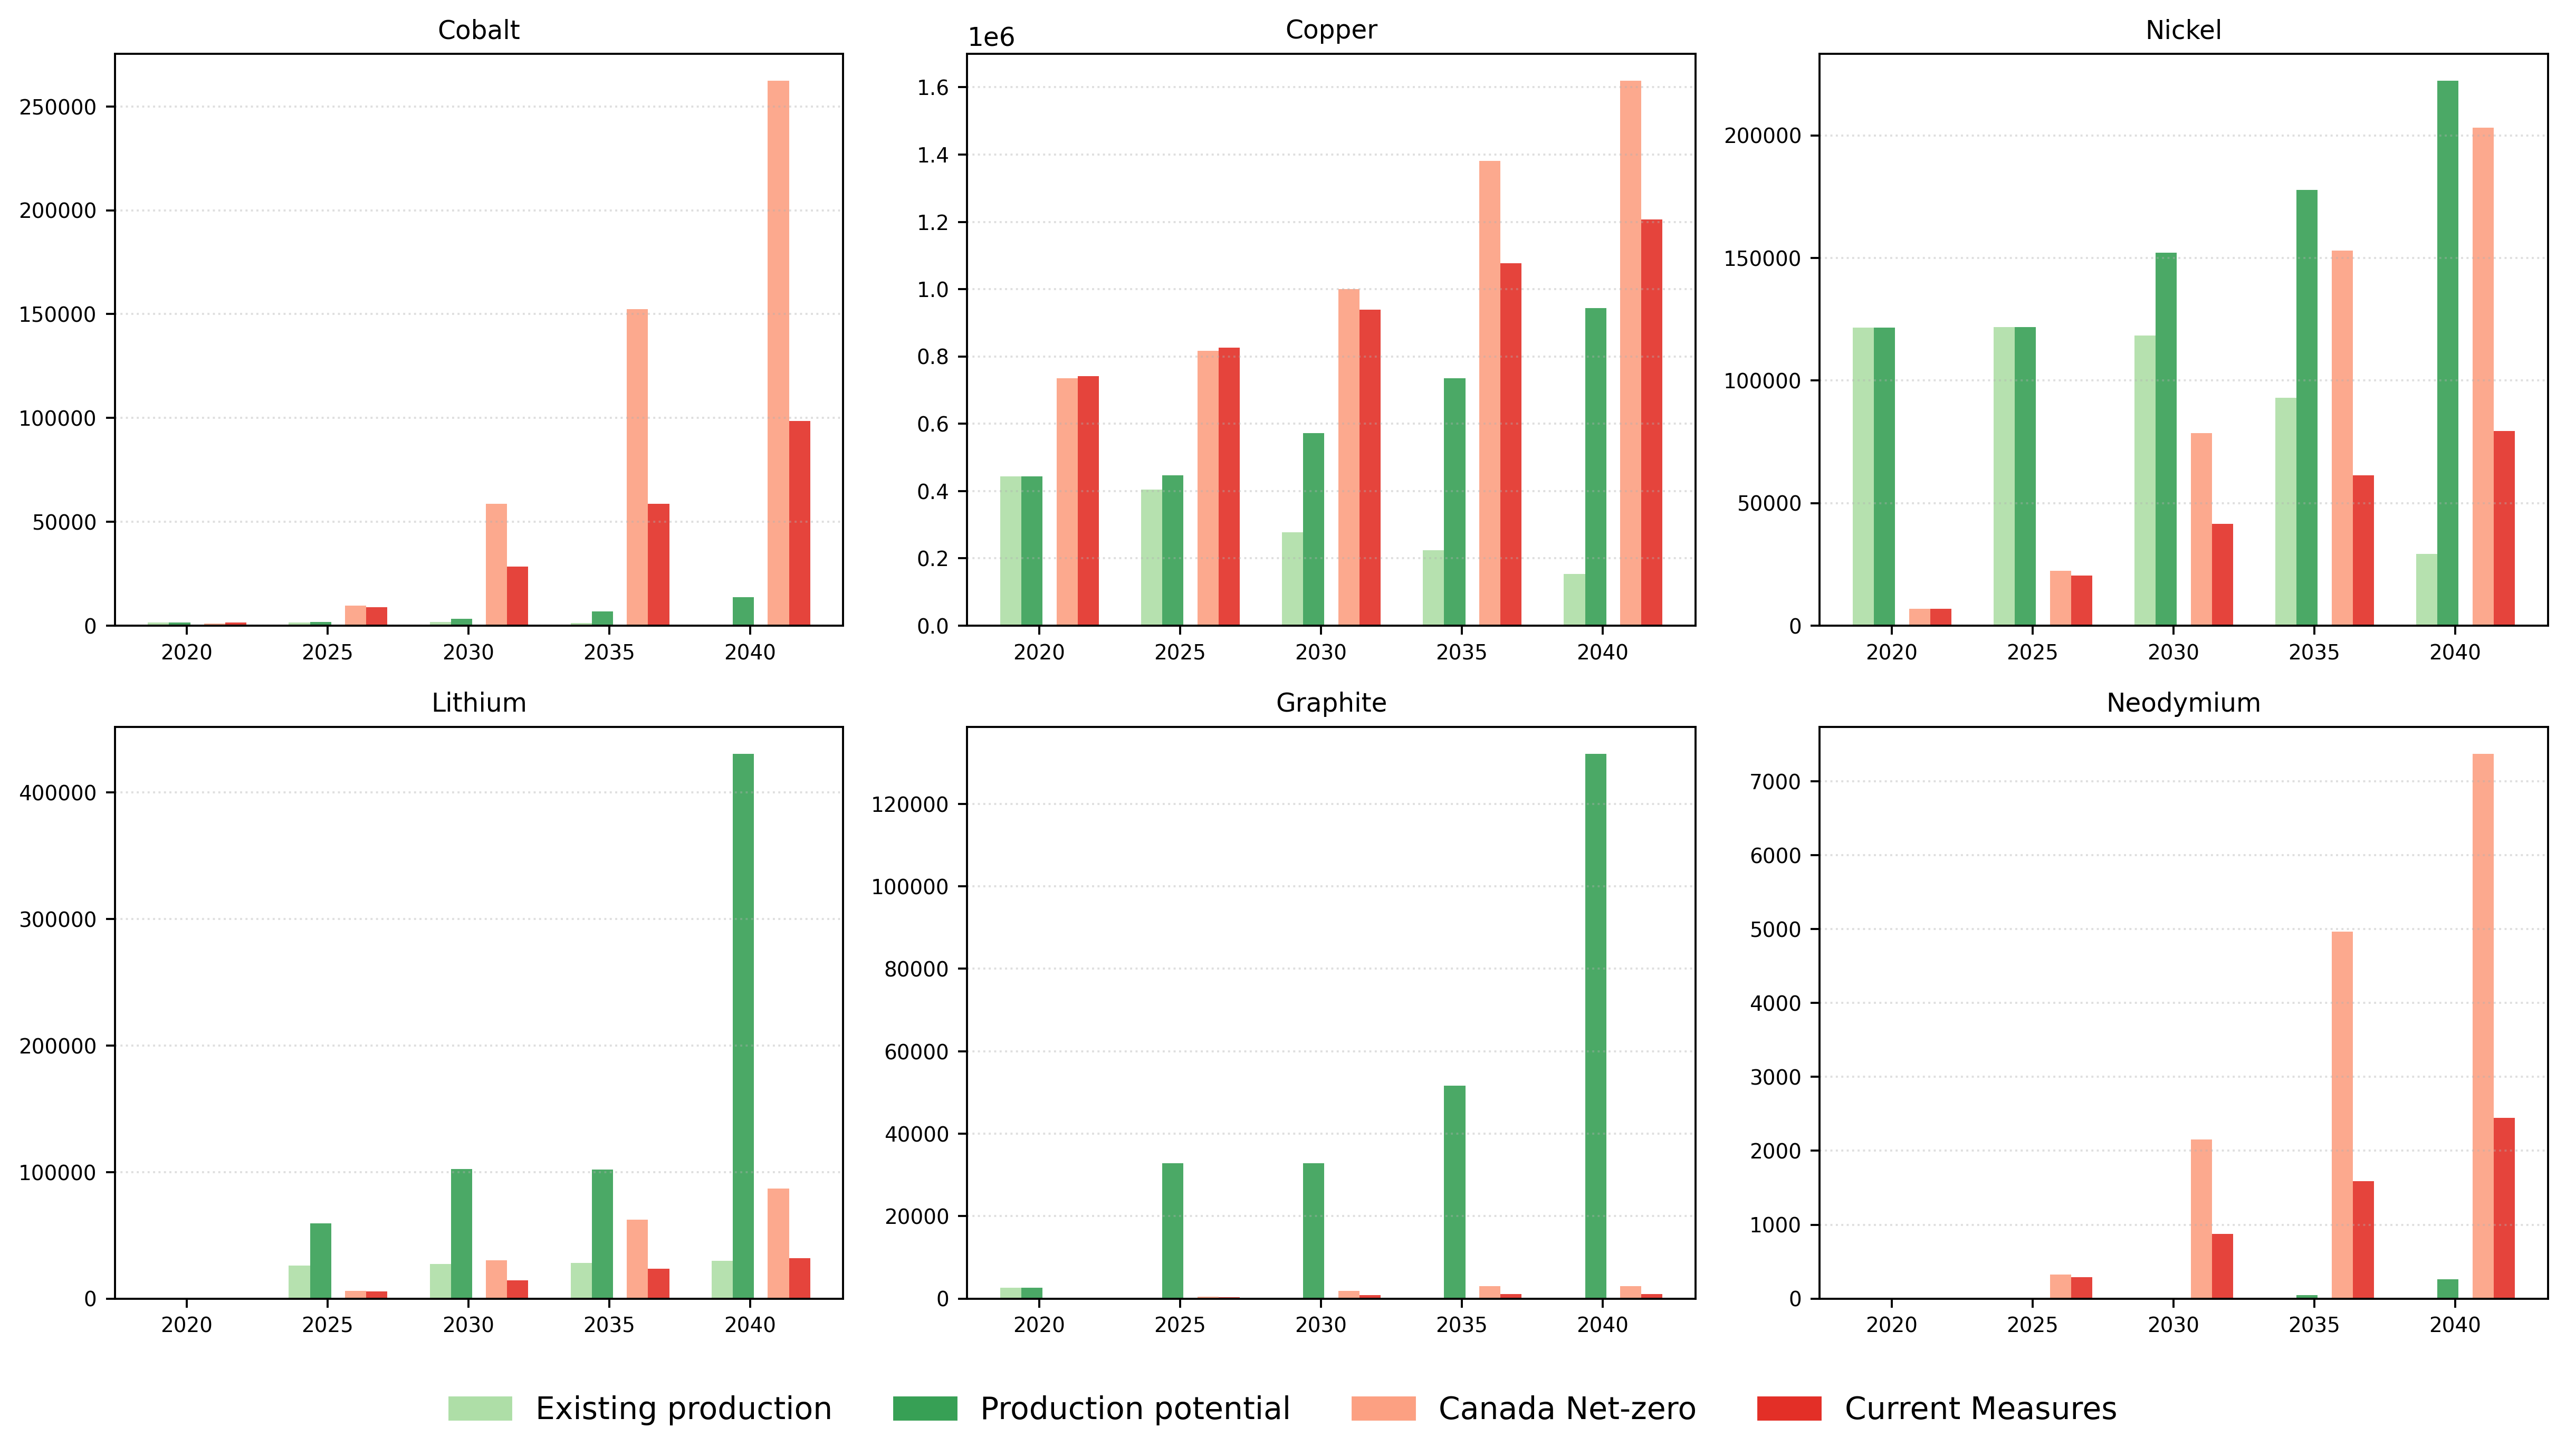

In [8]:
plot_prod_vs_demand_totals_facets_clean(df_prod, df_demand, metals=['Cobalt', 'Copper', 'Nickel', 'Lithium', 'Graphite', 'Neodymium'], savepath='results/Prod_vs_demand/Prod_vs_demand_selected_metals')